In this notebook we show that out estimator works in estimating the shape parameter of the tails of Generalised Pareto Distributions.
Ww will generate 100 distributions whose tails have shape parameters ranging form 0 to 5, and see is the estimator, can predict them correctly. We run the experiments several times and study the mean and variability of predictions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [2]:
def pickands_estimator(x,thresh,avg_size):
    y=x.copy()
    length=x.shape[0]
    #print('length: ', length)
    cutoff=int(thresh*length)
    #print('cutoff: ', cutoff)
    x=-np.sort(-np.sort(x, axis=0)[cutoff:], axis=0)
    #print('x.shape: ', x.shape)
    ksi=np.array([])
    #print('(length-cutoff)//4-1: ', (length-cutoff)//4-1)
    for j in np.arange(np.sqrt(length-cutoff))[-avg_size:]:
        k=int(j+1)
        #print(k)
        ksi=np.append(ksi,np.log((x[k]-x[2*k])/(x[2*k]-x[4*k]))/np.log(2))

       
    ksi=ksi.reshape(avg_size,-1)
    #for i in range(ksi.shape[1]):
        #print(i)
        #print(ksi[:,i])
        #plt.plot(ksi[:,i])
        #plt.savefig('/user/ehaxholl/home/Desktop/Plots/'+str(i)+'.png')
        #plt.show()
        #plt.clf()
    #print('ksi shape: ', ksi.shape)
    ksi=ksi.mean(0)
    return ksi


In [3]:
avg=[]
std=[]
for ksi in np.linspace(0.01,5,25):
    hist=[]
    for i in range(1000):
        x=np.random.rand(100000)
        y=x**(-ksi)
        hist.append(pickands_estimator(y,0.95,5))
    hist=np.array(hist)
    print('ksi: ',ksi,' pred_ksi: ',hist.mean())
    avg.append(hist.mean())
    std.append(hist.std())

ksi:  0.01  pred_ksi:  0.0014196437138763933
ksi:  0.21791666666666668  pred_ksi:  0.20726955277854117
ksi:  0.42583333333333334  pred_ksi:  0.41577946814142114
ksi:  0.63375  pred_ksi:  0.6266664533999176
ksi:  0.8416666666666667  pred_ksi:  0.8391126572336247
ksi:  1.0495833333333333  pred_ksi:  1.027111475755899
ksi:  1.2575  pred_ksi:  1.2557575086057426
ksi:  1.4654166666666666  pred_ksi:  1.455530672555037
ksi:  1.6733333333333333  pred_ksi:  1.654290710069387
ksi:  1.88125  pred_ksi:  1.8643197466458588
ksi:  2.0891666666666664  pred_ksi:  2.0699829961219653
ksi:  2.297083333333333  pred_ksi:  2.283140843837804
ksi:  2.505  pred_ksi:  2.4769722802171437
ksi:  2.7129166666666666  pred_ksi:  2.675224200367735
ksi:  2.920833333333333  pred_ksi:  2.912190398127414
ksi:  3.1287499999999997  pred_ksi:  3.1278170869561746
ksi:  3.3366666666666664  pred_ksi:  3.325324267417774
ksi:  3.544583333333333  pred_ksi:  3.5504995641521244
ksi:  3.7525  pred_ksi:  3.7586948964283606
ksi:  3.9604

In [4]:
avg=np.array(avg)
std=np.array(std)

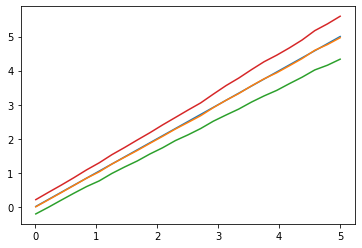

In [5]:
plt.plot(np.linspace(0.01,5,25),np.linspace(0.01,5,25))
plt.plot(np.linspace(0.01,5,25),avg)
plt.plot(np.linspace(0.01,5,25),avg-std)
plt.plot(np.linspace(0.01,5,25),avg+std)

In [6]:
def trunc(values, decs=0):
    return np.trunc(values*10**decs)/(10**decs)

In [7]:
dens=25

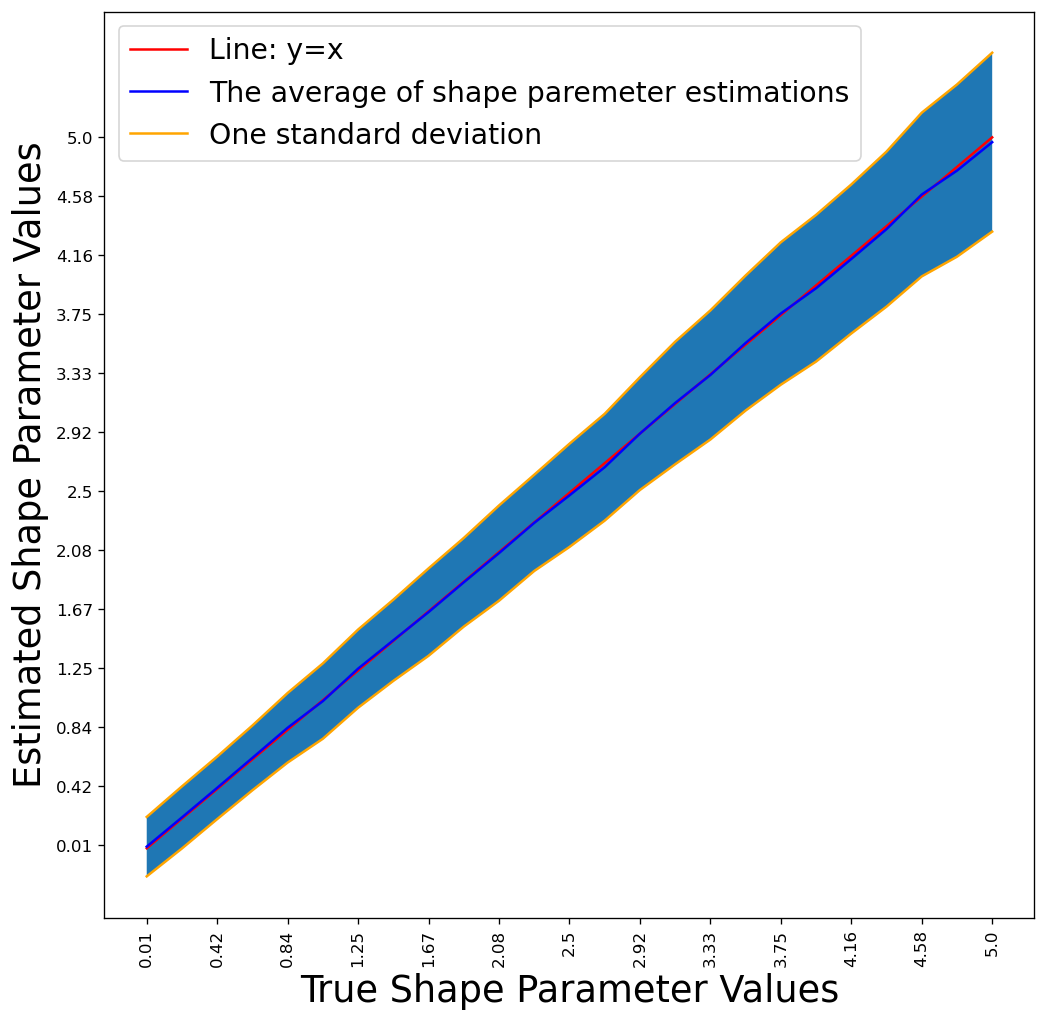

In [12]:
figure(figsize=(10, 10), dpi=120)
plt.plot(np.linspace(0.01,5,dens),np.linspace(-0.01,5,dens),color='red', label='Line: y=x')
plt.plot(np.linspace(0.01,5,dens),avg,color='blue', label='The average of shape paremeter estimations')
plt.plot(np.linspace(0.01,5,dens),avg-std,color='orange', label='One standard deviation')
plt.plot(np.linspace(0.01,5,dens),avg+std,color='orange')
plt.fill_between(np.linspace(0.01,5,dens),avg-std,avg+std)
plt.xlabel('True Shape Parameter Values',fontsize=22)
xticks_as_strings=trunc(np.linspace(0.01,5,dens), decs=2).astype(str)
plt.xticks(ticks=np.linspace(0.01,5,dens)[::2], labels=xticks_as_strings[::2])
plt.xticks(rotation=90)
plt.ylabel('Estimated Shape Parameter Values',fontsize=22)
yticks_as_strings=trunc(np.linspace(0.01,5,dens), decs=2).astype(str)
plt.yticks(ticks=np.linspace(0.01,5,dens)[::2], labels=yticks_as_strings[::2])
plt.yticks(rotation=0)
plt.legend(prop={"size":17})
#plt.savefig('Validity of our_implementation_of_Pickands_estimator2.jpg')